In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("trainLabels.csv.zip")
print(df.head())
print("Total rows:", len(df))

      image  level
0   10_left      0
1  10_right      0
2   13_left      0
3  13_right      0
4   15_left      1
Total rows: 35126


level
0    25810
1     2443
2     5292
3      873
4      708
Name: count, dtype: int64


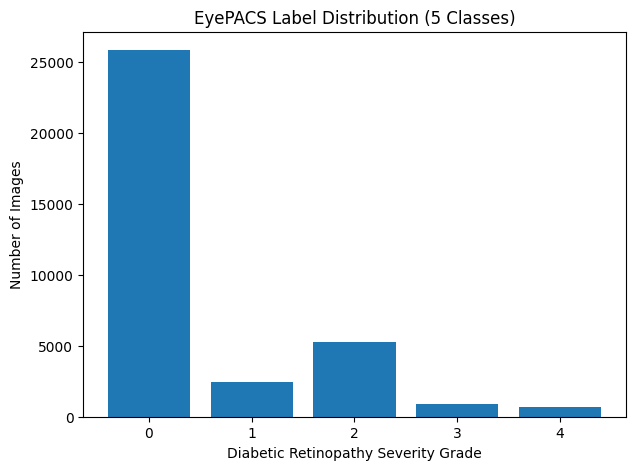

In [ ]:
class_counts = df["level"].value_counts().sort_index()
print(class_counts)

plt.figure(figsize=(7,5))
plt.bar(class_counts.index.astype(str), class_counts.values)
plt.xlabel("Diabetic Retinopathy Severity Grade")
plt.ylabel("Number of Images")
plt.title("EyePACS Label Distribution (5 Classes)")
plt.show()

In [ ]:
df["binary"] = (df["level"] > 0).astype(int)
binary_counts = df["binary"].value_counts().sort_index()
print(binary_counts)
print(binary_counts / binary_counts.sum())

binary
0    25810
1     9316
Name: count, dtype: int64
binary
0    0.734783
1    0.265217
Name: count, dtype: float64


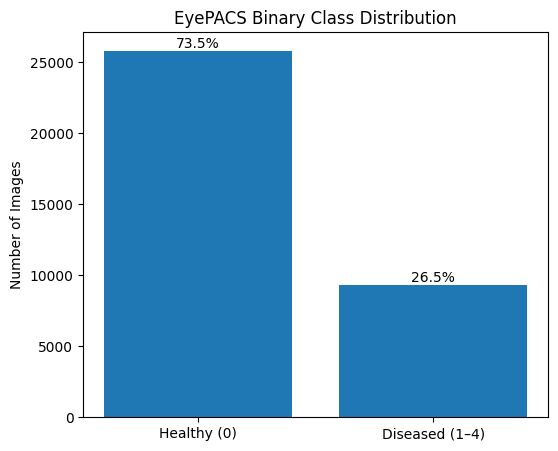

In [ ]:
labels = ["Healthy (0)", "Diseased (1–4)"]
values = binary_counts.values
percentages = values / values.sum() * 100

plt.figure(figsize=(6,5))
bars = plt.bar(labels, values)

for bar, pct in zip(bars, percentages):
    plt.text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height(),
        f"{pct:.1f}%",
        ha="center",
        va="bottom"
    )

plt.ylabel("Number of Images")
plt.title("EyePACS Binary Class Distribution")
plt.show()

In [ ]:
import zipfile
import os

os.makedirs("images", exist_ok=True)

with zipfile.ZipFile("subset_images.zip", "r") as z:
    z.extractall("images")

print("Done")
print(os.listdir("images")[:10])

Done
['9544_left.jpeg', '14153_left.jpeg', '35035_left.jpeg', '30567_right.jpeg', '39607_right.jpeg', '2131_left.jpeg', '13768_right.jpeg', '40228_left.jpeg', '41692_left.jpeg', '23982_right.jpeg']


In [ ]:
import os

image_files = set(os.listdir("images"))
label_files = set(df["image"] + ".jpeg")

missing = label_files - image_files

print("Missing images:", len(missing))
print(list(missing)[:10])

Missing images: 33126
['1179_left.jpeg', '30240_right.jpeg', '34971_right.jpeg', '28820_left.jpeg', '17734_right.jpeg', '18616_left.jpeg', '21083_left.jpeg', '9366_right.jpeg', '26991_left.jpeg', '30832_right.jpeg']


In [ ]:
df["filename"] = df["image"] + ".jpeg"

df = df[df["filename"].isin(os.listdir("images"))]

print("Remaining rows:", len(df))

Remaining rows: 2000


In [ ]:
from sklearn.model_selection import train_test_split

train_df, temp_df = train_test_split(
    df,
    test_size=0.3,
    stratify=df["binary"],
    random_state=42
)

val_df, test_df = train_test_split(
    temp_df,
    test_size=0.5,
    stratify=temp_df["binary"],
    random_state=42
)

print("Train:", len(train_df))
print("Validation:", len(val_df))
print("Test:", len(test_df))

Train: 1400
Validation: 300
Test: 300


In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from PIL import Image

class RetinopathyDataset(Dataset):
    def __init__(self, dataframe, image_dir, transform=None):
        self.dataframe = dataframe.reset_index(drop=True)
        self.image_dir = image_dir
        self.transform = transform

    def __len__(self):
        return len(self.dataframe)

    def __getitem__(self, idx):
        image_id = self.dataframe.loc[idx, "image"]
        label = int(self.dataframe.loc[idx, "binary"])
        image_path = os.path.join(self.image_dir, image_id + ".jpeg")

        image = Image.open(image_path).convert("RGB")

        if self.transform:
            image = self.transform(image)

        return image, label


In [ ]:
from torchvision import transforms, models

train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.ToTensor(),
])

eval_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
])

In [ ]:
print(os.listdir("images")[:10])

['9544_left.jpeg', '14153_left.jpeg', '35035_left.jpeg', '30567_right.jpeg', '39607_right.jpeg', '2131_left.jpeg', '13768_right.jpeg', '40228_left.jpeg', '41692_left.jpeg', '23982_right.jpeg']


In [ ]:
image_dir = "images"

train_dataset = RetinopathyDataset(train_df, image_dir, transform=train_transform)
val_dataset = RetinopathyDataset(val_df, image_dir, transform=eval_transform)
test_dataset = RetinopathyDataset(test_df, image_dir, transform=eval_transform)

train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=16, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=16, shuffle=False)


In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

model = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)
model.fc = nn.Linear(model.fc.in_features, 2)
model = model.to(device)

Using device: cpu
Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 99.9MB/s]


In [ ]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=1e-4)

In [ ]:
def run_epoch(loader, model, criterion, optimizer=None):
    training = optimizer is not None
    model.train() if training else model.eval()

    total_loss = 0
    correct = 0
    total = 0

    with torch.set_grad_enabled(training):
        for images, labels in loader:
            images, labels = images.to(device), labels.to(device)

            outputs = model(images)
            loss = criterion(outputs, labels)

            if training:
                optimizer.zero_grad()
                loss.backward()
                optimizer.step()

            total_loss += loss.item() * images.size(0)
            preds = outputs.argmax(dim=1)
            correct += (preds == labels).sum().item()
            total += labels.size(0)

    return total_loss / total, correct / total

In [ ]:
num_epochs = 10
train_losses = []
val_losses = []
train_accuracies = []
val_accuracies = []

for epoch in range(num_epochs):
    train_loss, train_acc = run_epoch(train_loader, model, criterion, optimizer)
    val_loss, val_acc = run_epoch(val_loader, model, criterion)
    train_losses.append(train_loss)
    val_losses.append(val_loss)
    train_accuracies.append(train_acc)
    val_accuracies.append(val_acc)


    print(f"Epoch {epoch+1}/{num_epochs}")
    print(f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f}")
    print(f"Val Loss:   {val_loss:.4f} | Val Acc:   {val_acc:.4f}")

Epoch 1/10
Train Loss: 0.7027 | Train Acc: 0.5829
Val Loss:   0.6102 | Val Acc:   0.6800
Epoch 2/10
Train Loss: 0.6322 | Train Acc: 0.6386
Val Loss:   0.6289 | Val Acc:   0.6700
Epoch 3/10
Train Loss: 0.5931 | Train Acc: 0.6764
Val Loss:   0.7331 | Val Acc:   0.6033
Epoch 4/10
Train Loss: 0.5423 | Train Acc: 0.7164
Val Loss:   0.6861 | Val Acc:   0.5933
Epoch 5/10
Train Loss: 0.5172 | Train Acc: 0.7429
Val Loss:   0.6269 | Val Acc:   0.6867
Epoch 6/10
Train Loss: 0.4829 | Train Acc: 0.7621
Val Loss:   0.7161 | Val Acc:   0.6267
Epoch 7/10
Train Loss: 0.4437 | Train Acc: 0.7821
Val Loss:   1.1463 | Val Acc:   0.5967
Epoch 8/10
Train Loss: 0.3854 | Train Acc: 0.8221
Val Loss:   0.7458 | Val Acc:   0.6733
Epoch 9/10
Train Loss: 0.3466 | Train Acc: 0.8443
Val Loss:   0.7231 | Val Acc:   0.6800
Epoch 10/10
Train Loss: 0.2822 | Train Acc: 0.8814
Val Loss:   0.8732 | Val Acc:   0.6833


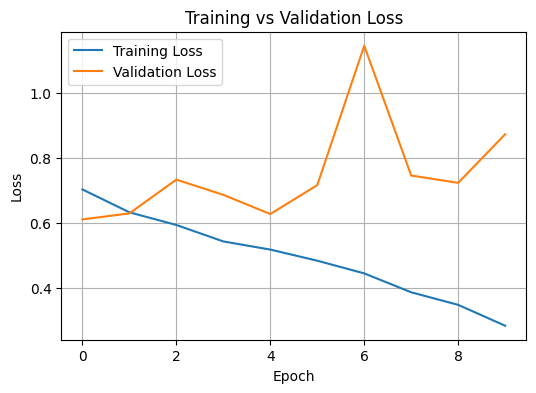

In [ ]:
plt.figure(figsize=(6,4))
plt.plot(train_losses, label="Training Loss")
plt.plot(val_losses, label="Validation Loss")

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training vs Validation Loss")
plt.legend()
plt.grid()

plt.show()

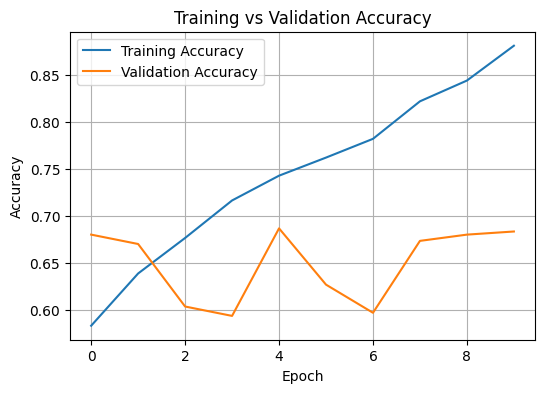

In [ ]:
plt.figure(figsize=(6,4))
plt.plot(train_accuracies, label="Training Accuracy")
plt.plot(val_accuracies, label="Validation Accuracy")

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training vs Validation Accuracy")
plt.legend()
plt.grid()

plt.show()

In [ ]:
all_preds = []
all_labels = []

model.eval()
with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        outputs = model(images)
        preds = outputs.argmax(dim=1).cpu().numpy()

        all_preds.extend(preds)
        all_labels.extend(labels.numpy())

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix
cm = confusion_matrix(all_labels, all_preds)
print(cm)
print(classification_report(all_labels, all_preds, target_names=["Healthy", "Diseased"]))

[[ 95  55]
 [ 41 109]]
              precision    recall  f1-score   support

     Healthy       0.70      0.63      0.66       150
    Diseased       0.66      0.73      0.69       150

    accuracy                           0.68       300
   macro avg       0.68      0.68      0.68       300
weighted avg       0.68      0.68      0.68       300



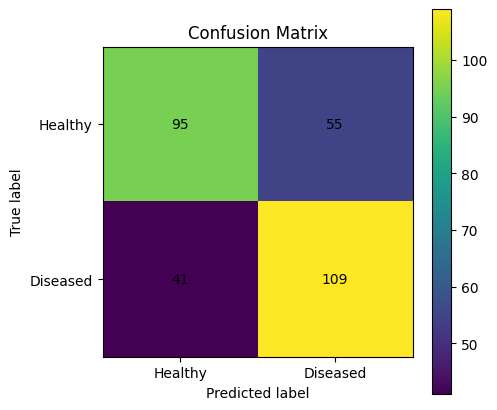

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(5,5))
plt.imshow(cm, interpolation="nearest")
plt.title("Confusion Matrix")
plt.colorbar()
plt.xticks([0,1], ["Healthy", "Diseased"])
plt.yticks([0,1], ["Healthy", "Diseased"])
plt.xlabel("Predicted label")
plt.ylabel("True label")

for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(j, i, cm[i, j], ha="center", va="center")

plt.show()

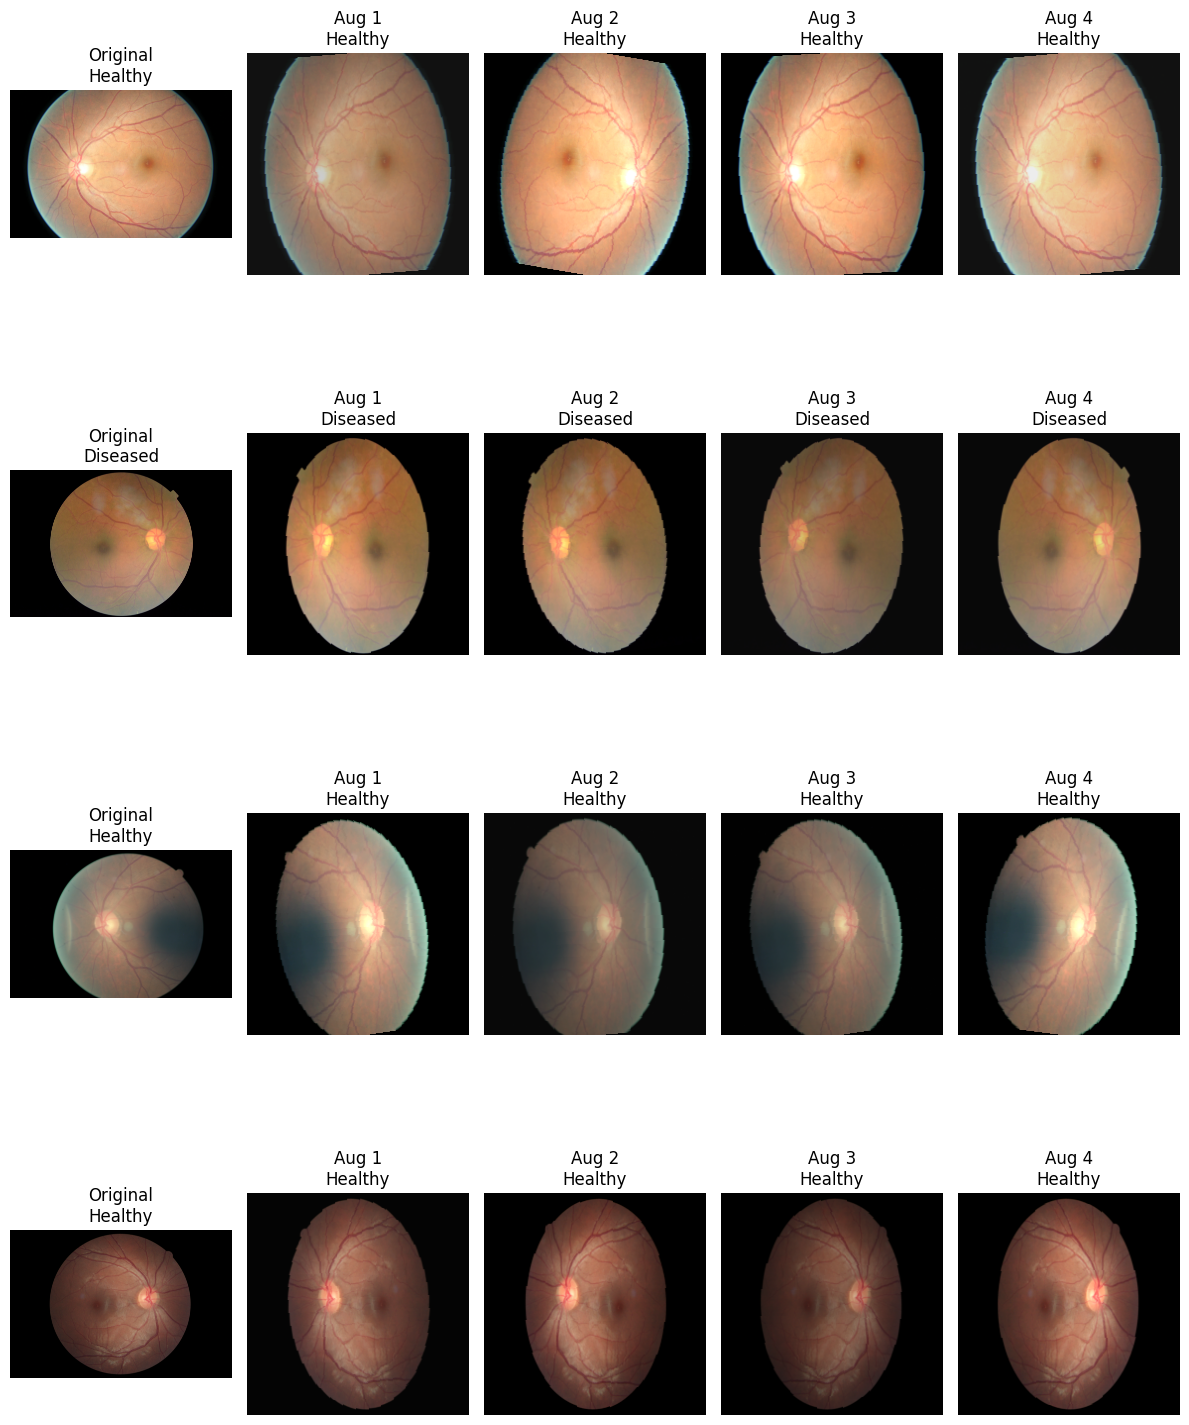

In [ ]:
import numpy as np
num_samples = 4
image_dir = "/content/images"

train_df["image_path"] = image_dir + "/" + train_df["filename"]
sample_path = train_df.iloc[0]["image_path"]
sample_df = train_df.sample(num_samples)

plt.figure(figsize=(12, 4 * num_samples))

for row_idx, (_, row) in enumerate(sample_df.iterrows()):
    img = Image.open(row["image_path"]).convert("RGB")

    # Convert label to text
    label = "Healthy" if row["binary"] == 0 else "Diseased"

    # Generate augmentations
    augmented_images = [train_transform(img) for _ in range(4)]

    # Original image
    plt.subplot(num_samples, 5, row_idx * 5 + 1)
    plt.imshow(img)
    plt.title(f"Original\n{label}")
    plt.axis("off")

    # Augmented images
    for i, aug_img in enumerate(augmented_images):
        plt.subplot(num_samples, 5, row_idx * 5 + i + 2)

        aug_img = aug_img.permute(1, 2, 0).numpy()
        aug_img = np.clip(aug_img, 0, 1)

        plt.imshow(aug_img)
        plt.title(f"Aug {i+1}\n{label}")
        plt.axis("off")

plt.tight_layout()
plt.show()

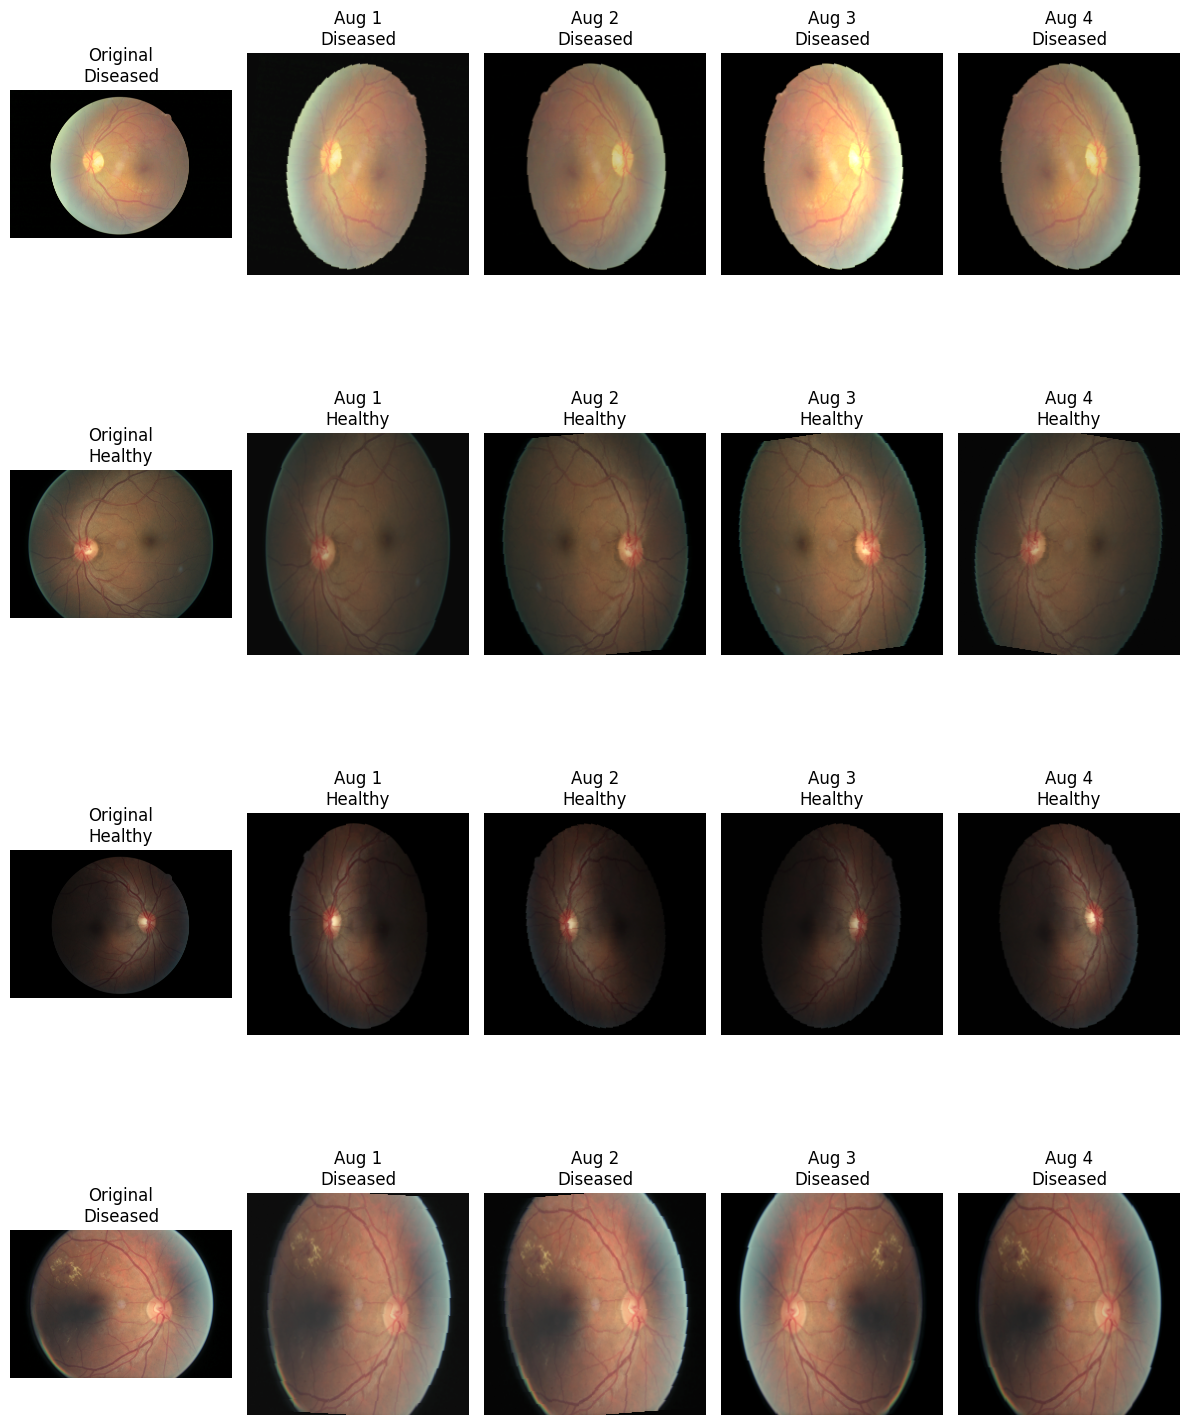

In [ ]:
import numpy as np
num_samples = 4
image_dir = "/content/images"

train_df["image_path"] = image_dir + "/" + train_df["filename"]
sample_path = train_df.iloc[0]["image_path"]
sample_df = train_df.sample(num_samples)

plt.figure(figsize=(12, 4 * num_samples))

for row_idx, (_, row) in enumerate(sample_df.iterrows()):
    img = Image.open(row["image_path"]).convert("RGB")

    # Convert label to text
    label = "Healthy" if row["binary"] == 0 else "Diseased"

    # Generate augmentations
    augmented_images = [train_transform(img) for _ in range(4)]

    # Original image
    plt.subplot(num_samples, 5, row_idx * 5 + 1)
    plt.imshow(img)
    plt.title(f"Original\n{label}")
    plt.axis("off")

    # Augmented images
    for i, aug_img in enumerate(augmented_images):
        plt.subplot(num_samples, 5, row_idx * 5 + i + 2)

        aug_img = aug_img.permute(1, 2, 0).numpy()
        aug_img = np.clip(aug_img, 0, 1)

        plt.imshow(aug_img)
        plt.title(f"Aug {i+1}\n{label}")
        plt.axis("off")

plt.tight_layout()
plt.show()